## Exercise 1.1

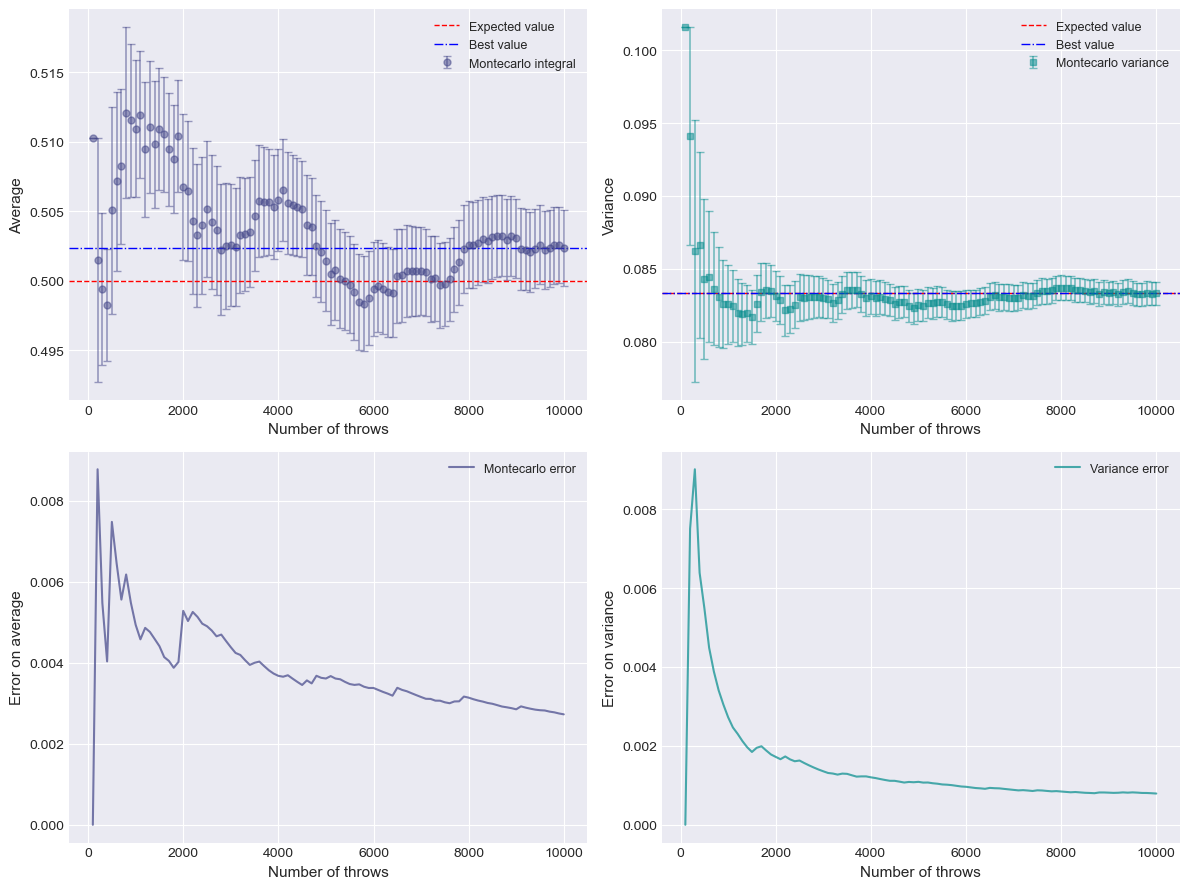

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Stile compatto
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 9
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['lines.markersize'] = 5
plt.style.use('seaborn-v0_8-darkgrid')

# Caricamento dati
file_avg = "Exercise_1_1/output_average.data"
x1, y1, error1 = np.loadtxt(file_avg, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x3, y3 = np.loadtxt(file_avg, usecols=(0, 2), delimiter='\t', unpack=True)

file_var = "Exercise_1_1/output_variance.data"
x2, y2, error2 = np.loadtxt(file_var, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x4, y4 = np.loadtxt(file_var, usecols=(0, 2), delimiter='\t', unpack=True)

# Colori
viridis = plt.cm.viridis
color_avg = viridis(0.2)
color_var = 'darkcyan'

# Figure e assi
fig, axs = plt.subplots(2, 2, figsize=(12, 9))

# Media
axs[0, 0].errorbar(x1, y1, yerr=error1, fmt='o', color=color_avg,
                   capsize=3, elinewidth=1.2, alpha=0.5, label='Montecarlo integral')
axs[0, 0].axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Expected value')
axs[0, 0].axhline(y=y1[99], color='blue', linestyle='-.', linewidth=1, label='Best value')
axs[0, 0].set_xlabel('Number of throws')
axs[0, 0].set_ylabel('Average')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Varianza
axs[0, 1].errorbar(x2, y2, yerr=error2, fmt='s', color=color_var,
                   capsize=3, elinewidth=1.2, alpha=0.5, label='Montecarlo variance')
axs[0, 1].axhline(y=1./12., color='red', linestyle='--', linewidth=1, label='Expected value')
axs[0, 1].axhline(y=y2[99], color='blue', linestyle='-.', linewidth=1, label='Best value')
axs[0, 1].set_xlabel('Number of throws')
axs[0, 1].set_ylabel('Variance')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Errore sulla media (linea)
axs[1, 0].plot(x3, y3, '-', color=color_avg, alpha=0.7, label='Montecarlo error')
axs[1, 0].set_xlabel('Number of throws')
axs[1, 0].set_ylabel('Error on average')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Errore sulla varianza (linea)
axs[1, 1].plot(x4, y4, '-', color=color_var, alpha=0.7, label='Variance error')
axs[1, 1].set_xlabel('Number of throws')
axs[1, 1].set_ylabel('Error on variance')
axs[1, 1].legend()
axs[1, 1].grid(True)

# Layout finale
plt.tight_layout()
plt.show()


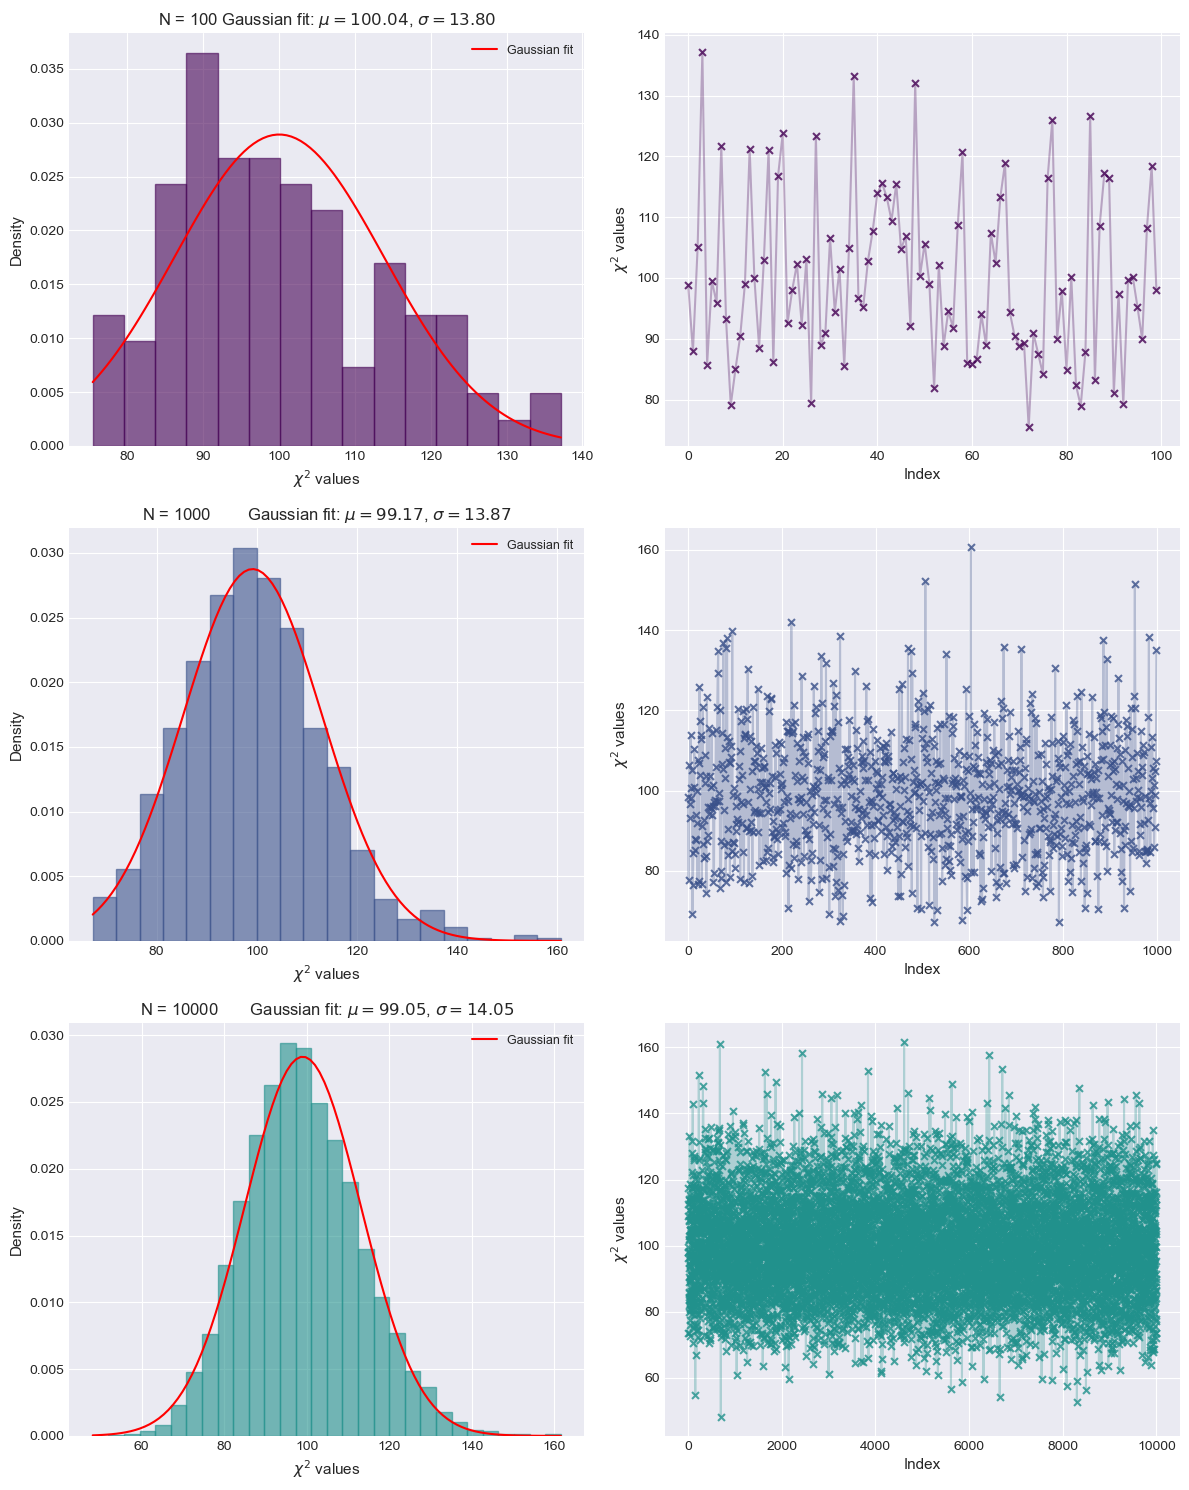

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.colors as mcolors

def read_data(file):
    with open(file, 'r') as f:
        data = [float(line.strip()) for line in f]
    return data

def plot_data(file_counts, file_chi, ax_index, title, color, bins):
    data_counts = read_data(file_counts)
    data_chi = read_data(file_chi)
    mu, sigma = norm.fit(data_chi) 

    axs[ax_index, 0].hist(
        data_chi, bins=bins, color=color, alpha=0.6, edgecolor=color, density=True
    )
    axs[ax_index, 0].set_xlabel('$\\chi^2$ values')
    axs[ax_index, 0].set_ylabel('Density')
    axs[ax_index, 0].set_title(f'{title}\tGaussian fit: $\\mu = {mu:.2f}$, $\\sigma = {sigma:.2f}$')

    
    x_vals = np.linspace(np.min(data_chi), np.max(data_chi), 100)
    y_vals = norm.pdf(x_vals, mu, sigma)
    axs[ax_index, 0].plot(x_vals, y_vals, 'r-', label='Gaussian fit')
    axs[ax_index, 0].legend()

    
    axs[ax_index, 1].scatter(
        range(len(data_chi)), data_chi, color=color, marker='x', alpha=0.8
    )
    axs[ax_index, 1].plot(
        range(len(data_chi)), data_chi, linestyle='-', color=color, alpha=0.3
    )
    axs[ax_index, 1].set_xlabel('Index')
    axs[ax_index, 1].set_ylabel('$\\chi^2$ values')

# --- main ---

fig, axs = plt.subplots(3, 2, figsize=(12, 15))
files = [
    ('Exercise_1_1/output_counts_100.data', 'Exercise_1_1/output_chi_100.data', 'N = 100', 15),
    ('Exercise_1_1/output_counts_1000.data', 'Exercise_1_1/output_chi_1000.data', 'N = 1000', 20),
    ('Exercise_1_1/output_counts_10000.data', 'Exercise_1_1/output_chi_10000.data', 'N = 10000', 30)
]

# Viridis color palette
viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(files)+2))
hex_colors = [mcolors.to_hex(c) for c in viridis_colors]

# Genera i plot
for i, (file_counts, file_chi, title, bins) in enumerate(files):
    plot_data(file_counts, file_chi, i, title, hex_colors[i], bins)

plt.tight_layout()
plt.show()


# Exercise 1.2

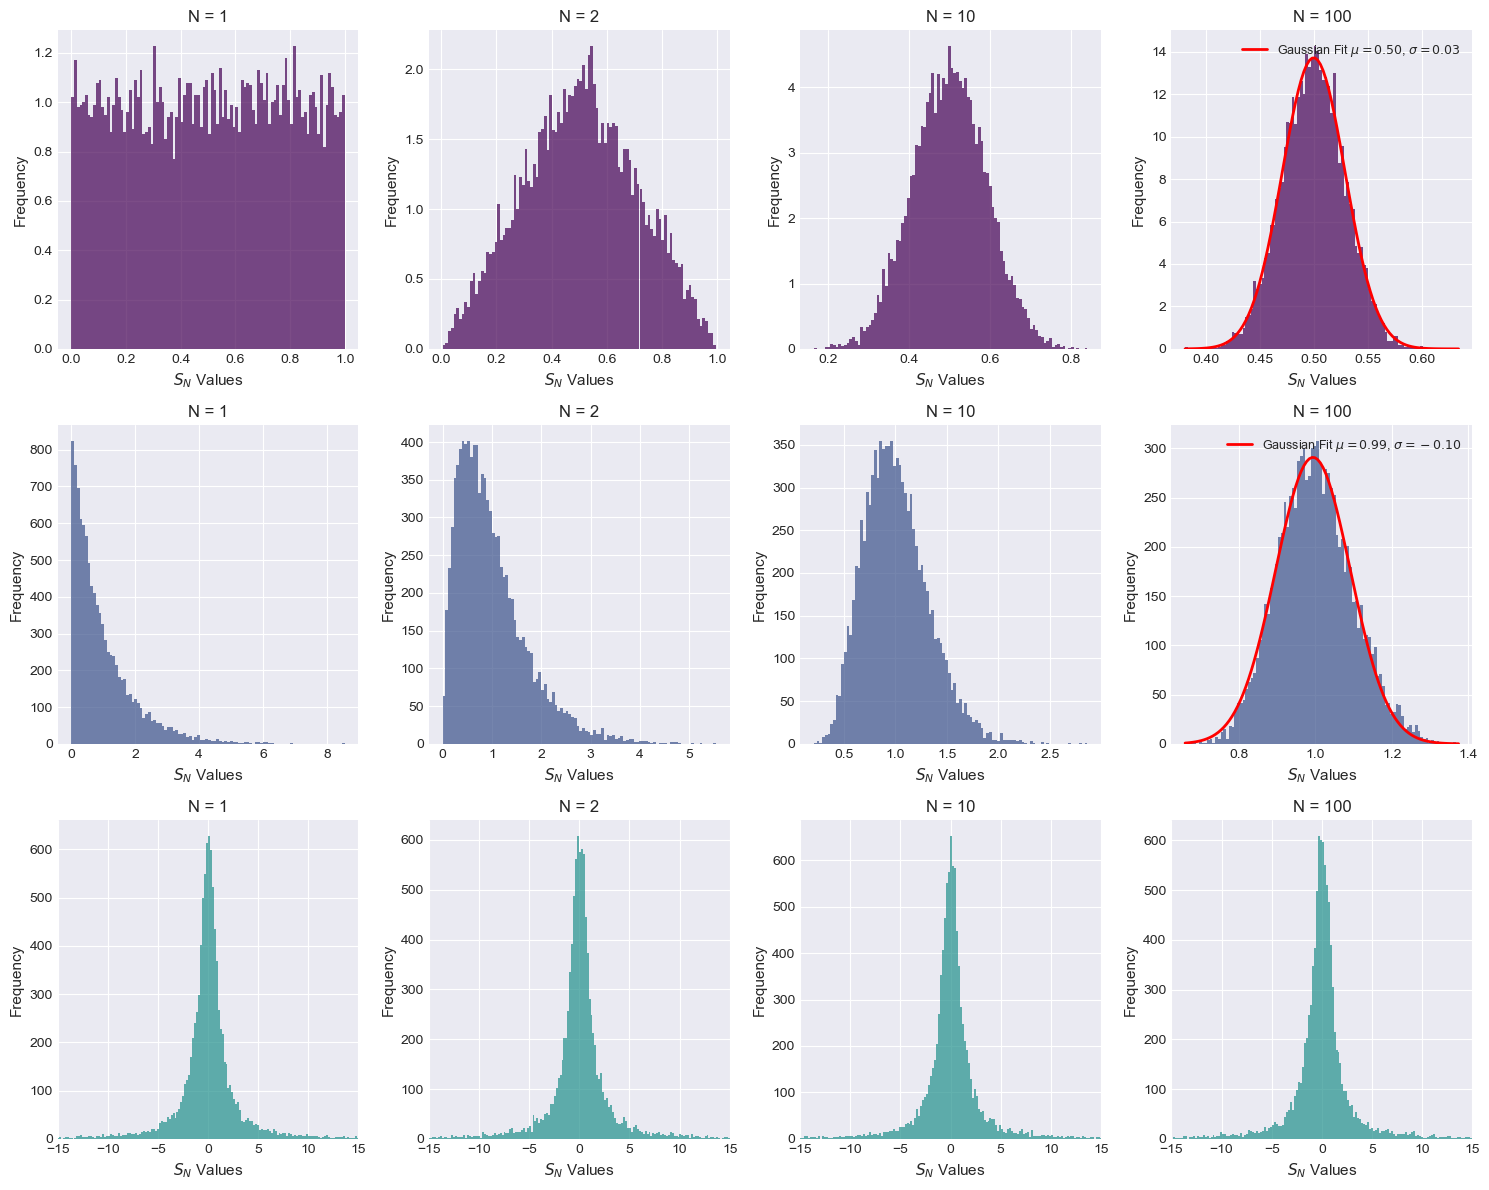

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# Define Gaussian function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

filenames = {
    "1": "Exercise_1_2/output_N1.txt",
    "2": "Exercise_1_2/output_N2.txt",
    "10": "Exercise_1_2/output_N10.txt",
    "100": "Exercise_1_2/output_N100.txt"
}

viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(filenames) + 1))
hex_colors = [mcolors.to_hex(c) for c in viridis_colors]

fig, axs = plt.subplots(3, 4, figsize=(15, 12))

for idx, (N_label, filename) in enumerate(filenames.items()):
    try:
        data = np.loadtxt(filename, skiprows=1)

        # Plot first column
        hist_data, bins, _ = axs[0, idx].hist(data[:, 0], bins=100, alpha=0.7, color=hex_colors[0], density=True)
        axs[0, idx].set_xlabel("$S_N$ Values")
        axs[0, idx].set_ylabel("Frequency")
        axs[0, idx].set_title(f"N = {N_label}")
        axs[0, idx].grid(True)

        # Fit Gaussian for N=100
        if N_label == "100":
            bin_centers = (bins[:-1] + bins[1:]) / 2  # Get bin centers
            popt, _ = curve_fit(gaussian, bin_centers, hist_data, p0=[1, np.mean(data[:, 0]), np.std(data[:, 0])])
            x = np.linspace(min(data[:, 0]), max(data[:, 0]), 100)
            axs[0, idx].plot(x, gaussian(x, *popt), color='red', lw=2, label=rf'Gaussian Fit $\mu={popt[1]:.2f}$, $\sigma={popt[2]:.2f}$')
            axs[0, idx].legend()

        # Plot second column
        hist_data, bins, _ = axs[1, idx].hist(data[:, 1], bins=100, alpha=0.7, color=hex_colors[1])
        axs[1, idx].set_xlabel("$S_N$ Values")
        axs[1, idx].set_ylabel("Frequency")
        axs[1, idx].set_title(f"N = {N_label}")
        axs[1, idx].grid(True)

        # Fit Gaussian for N=100
        if N_label == "100":
            bin_centers = (bins[:-1] + bins[1:]) / 2
            popt, _ = curve_fit(gaussian, bin_centers, hist_data, p0=[1, np.mean(data[:, 1]), np.std(data[:, 1])])
            x = np.linspace(min(data[:, 1]), max(data[:, 1]), 100)
            axs[1, idx].plot(x, gaussian(x, *popt), color='red', lw=2, label=rf'Gaussian Fit $\mu={popt[1]:.2f}$, $\sigma={popt[2]:.2f}$')
            axs[1, idx].legend()

        # Plot third column
        filtered_data = data[:, 2][(data[:, 2] >= -50) & (data[:, 2] <= 50)]
        axs[2, idx].hist(filtered_data, bins=500, alpha=0.7, color=hex_colors[2])
        axs[2, idx].set_xlabel("$S_N$ Values")
        axs[2, idx].set_ylabel("Frequency")
        axs[2, idx].set_xlim(-15., 15.)
        axs[2, idx].set_title(f"N = {N_label}")
        axs[2, idx].grid(True)

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# Adjust layout
plt.tight_layout()
plt.show()


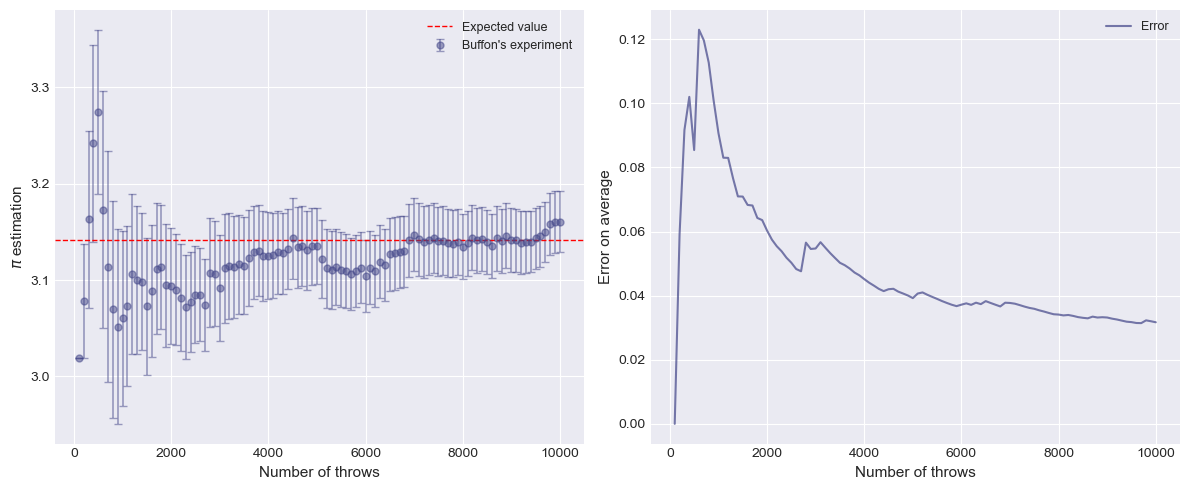

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Stile compatto
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 9
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['lines.markersize'] = 5

# Load data
file1 = "Exercise_1_3/output_average.data"
x1, y1, error1 = np.loadtxt(file1, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x2, y2 = np.loadtxt(file1, usecols=(0, 2), delimiter='\t', unpack=True)

# Viridis color
viridis = plt.cm.viridis
color_std = viridis(0.2)  
color_err = viridis(0.2)
ref_color = viridis(0.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Primo plot: stima di π
axes[0].errorbar(x1, y1, yerr=error1, fmt='o', color=color_std,
                 capsize=2, elinewidth=1.2, alpha=0.5, label='Buffon\'s experiment')
axes[0].axhline(y=np.pi, color='red', linestyle='--', linewidth=1, label='Expected value')
axes[0].axhline(y=y1[99], color='blue', linestyle='-.', linewidth=1, label='Best value')
axes[0].set_xlabel('Number of throws')
axes[0].set_ylabel(r'$\pi$ estimation')
axes[0].legend()
axes[0].grid(True)

# Secondo plot: errore
axes[1].plot(x2, y2, '-', color=color_err, alpha=0.7, label='Error')
axes[1].set_xlabel('Number of throws')
axes[1].set_ylabel('Error on average')
axes[1].legend()
axes[1].grid(True)

# Layout finale
plt.tight_layout()
plt.show()
